# Tabular Q-Learning: from the Bellman equation to code

Q-Learning estimates the **optimal action-value function**

$$
Q^*(s,a)=\max_\pi\;\mathbb{E}_\pi\!\left[\sum_{k=0}^{\infty}\gamma^k r_{t+k+1}\,\middle|\,s_t=s,\,a_t=a\right],
$$

which is the best expected discounted return obtainable after taking action $a$ in state $s$. Because Taxi has finite discrete state and action spaces, these estimates fit in a table

$$
Q\in\mathbb{R}^{|\mathcal S|\times|\mathcal A|}.
$$

Each row represents a state and each column an action. The setup cell below creates this table, initializes every estimate to zero, and defines the main hyperparameters:

- $\alpha$ (`LEARNING_RATE`) controls how strongly one new transition changes an estimate.
- $\gamma$ (`GAMMA`) controls the importance of future rewards.
- $\varepsilon$ controls the exploration–exploitation trade-off.

In [75]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

TOTAL_TIMESTEPS = 100_000
LEARNING_RATE = 0.2
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.05
EXPLORATION_STEPS = 50_000

env = gym.make("Taxi-v4")
q_table = np.zeros((env.observation_space.n, env.action_space.n), dtype=np.float32)

print("Q-table shape:", q_table.shape)

Q-table shape: (500, 6)


## 1. Explore while learning

If the agent always chooses the action with the largest initial estimate, it may never discover better alternatives. An **$\varepsilon$-greedy behavior policy** balances exploration and exploitation:

$$
a_t=\begin{cases}
\text{a uniformly random action}, & u<\varepsilon_t,\\
\displaystyle\arg\max_a Q(s_t,a), & u\geq\varepsilon_t,
\end{cases}\qquad u\sim\mathcal U(0,1).
$$

Early in training, a large $\varepsilon_t$ produces broad exploration. As estimates improve, reducing $\varepsilon_t$ makes the behavior increasingly greedy. The code below uses the clipped linear schedule

$$
\varepsilon_t=\operatorname{clip}\!\left(\varepsilon_{\text{start}}-\frac{t}{T},\;\varepsilon_{\text{end}},\;\varepsilon_{\text{start}}\right),
$$

where $T$ is `EXPLORATION_STEPS`. `greedy_policy` implements the $\arg\max$, `random_policy` samples an action uniformly, and `select_action` samples from the resulting behavior policy.

Q-Learning is **off-policy**: transitions come from this exploratory behavior policy, but the learning target assumes the next action will be greedy.

In [ ]:
def epsilon_at(step):
    """Return the linearly decayed exploration rate for this step."""
    fraction = min(step / EXPLORATION_STEPS, 1.0)
    return EPSILON_START + fraction * (EPSILON_END - EPSILON_START)

def greedy_policy(state):
    q_values = q_table[state]
    return np.argmax(q_values)

def random_policy():
    return np.random.choice(q_table.shape[1])

def select_action(state, step):
    """Select one epsilon-greedy action for a discrete state."""
    epsilon = epsilon_at(step)    
    if np.random.rand() > epsilon:
        return greedy_policy(state)
    else:
        return random_policy()

## 2. Learn from one transition

Suppose the environment produces the transition $(s_t,a_t,r_{t+1},s_{t+1})$. The Bellman optimality equation suggests the one-step target

$$
y_t=r_{t+1}+\gamma(1-d_t)\max_{a'}Q(s_{t+1},a'),
$$

where $d_t=1$ only when the transition truly **terminates** the Markov decision process. The difference between this target and the current estimate is the temporal-difference error

$$
\delta_t=y_t-Q(s_t,a_t).
$$

The agent moves the visited table entry a fraction $\alpha$ toward the target:

$$
Q(s_t,a_t)\leftarrow Q(s_t,a_t)+\alpha\,\delta_t.
$$

This is a **bootstrapped** update: the new estimate uses another estimate, $\max_{a'}Q(s_{t+1},a')$. If `terminated` is true, $(1-d_t)=0$ removes that future value. A Gymnasium time-limit `truncated` signal still bootstraps because the underlying task itself may not have ended.

In [77]:
def update_q_table(state, action, reward, next_state, terminated):
    """Apply one Q-Learning update and return the TD error."""
    y = reward + GAMMA * q_table[next_state, :].max() * (1 - terminated)
    td_error = y - q_table[state, action]
    q_table[state, action] += LEARNING_RATE * td_error

## 3. Turn updates into a training loop

Tabular one-step Q-Learning can learn **online**, without a replay buffer. At every environment step, the loop performs the same cycle:

1. observe $s_t$ and sample $a_t$ with the $\varepsilon$-greedy policy;
2. collect $(r_{t+1},s_{t+1},\texttt{terminated},\texttt{truncated})$;
3. update the single entry $Q(s_t,a_t)$;
4. reset after `terminated or truncated`, otherwise continue from $s_{t+1}$.

In [78]:
def train(total_timesteps):
    """Collect transitions, update the table, and return episode returns."""
    episode_returns = []
    episode_return = 0.0
    state, _ = env.reset()

    for step in range(total_timesteps):
        action = select_action(state, step)
        next_state, reward, terminated, truncated, info = env.step(action)
        update_q_table(state, action, reward, next_state, terminated)
        episode_return += reward
        
        state = next_state
        
        if terminated or truncated:
            episode_returns.append(episode_return)
            episode_return = 0.0
            state, _ = env.reset()
            
    env.close()
    return episode_returns


episode_returns = train(TOTAL_TIMESTEPS)

print(f"Trained for {len(episode_returns)} episodes.")

Trained for 3705 episodes.


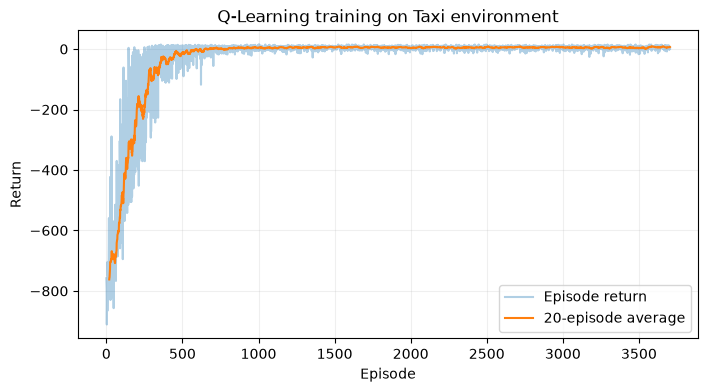

In [79]:
returns = np.asarray(episode_returns)
window = min(20, len(returns))
moving_average = np.convolve(returns, np.ones(window) / window, mode="valid")

plt.figure(figsize=(8, 4))
plt.plot(returns, alpha=0.35, label="Episode return")
plt.plot(
    np.arange(window - 1, len(returns)),
    moving_average,
    label=f"{window}-episode average",
)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title(f"Q-Learning training on Taxi environment")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 4. Evaluate the greedy policy

Training behavior remains exploratory, so its episode returns do not isolate what the Q-table has learned. During evaluation, set exploration aside and choose

$$
\pi_{\text{greedy}}(s)=\arg\max_a Q(s,a).
$$


In [80]:
env = gym.make("Taxi-v4", render_mode="human")

max_episodes = 5
max_steps = 100

episode_returns = []
for episode in range(max_episodes):
    
    episode_return = 0.0
    state, _ = env.reset()
    for step in range(max_steps):
        action = greedy_policy(state)
        state, reward, terminated, truncated, info = env.step(action)
        episode_return += reward
        
        if terminated or truncated:
            break
        
    print(f"Episode {episode + 1} {"terminated" if terminated else "truncated"}: steps={step + 1}, return={episode_return}")
    episode_returns.append(episode_return)
            
env.close()
        
print(f"Mean return: {np.mean(episode_returns):.1f} +/- {np.std(episode_returns):.1f}")

Episode 1 terminated: steps=7, return=14.0
Episode 2 terminated: steps=13, return=8.0
Episode 3 terminated: steps=12, return=9.0
Episode 4 terminated: steps=10, return=11.0
Episode 5 terminated: steps=13, return=8.0
Mean return: 10.0 +/- 2.3
